# Benchmark Group 2: Spatio-Temporal Generalization
This notebook evaluates the model's ability to generalize across different spatial locations and temporal periods.
In spatial and environmental sciences, dealing with spatial and temporal autocorrelation is crucial. Standard random K-Fold CV overestimates performance. We use Spatial CV and Temporal CV.

**Techniques Included:**
- Spatial Cross-Validation (Leave-Station-Out)
- Temporal Cross-Validation (e.g., Leave-Month-Out)
- Performance mapping across seasons

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

# Set plotting style for academic papers
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ---------------------------------------------------------
# 1. DATA GENERATION (Simulating a Spatio-Temporal Dataset)
# ---------------------------------------------------------
# In a real scenario, load your dataframe containing ['station_id', 'date', 'y_true', 'y_pred', 'season']
np.random.seed(42)

n_stations = 15
days = 365

data = []
for station_id in range(n_stations):
    # Baseline pollution level for the station
    base_pm = np.random.uniform(15, 45)
    for day in range(days):
        # Simulate seasonal effect (higher in winter/dry season)
        season_effect = 15 * np.cos(2 * np.pi * day / 365)
        
        true_val = max(5, base_pm + season_effect + np.random.normal(0, 10))
        
        # Simulate model prediction (with some station-specific bias and noise)
        pred_val = max(0, true_val * 0.85 + np.random.normal(0, 8) + np.random.uniform(-5, 5))
        
        # Assign season (0: Spring, 1: Summer, 2: Autumn, 3: Winter)
        month = (day // 30) % 12
        season = 'Winter' if month in [11, 0, 1] else 'Spring' if month in [2, 3, 4] else 'Summer' if month in [5, 6, 7] else 'Autumn'
        
        data.append({
            'station_id': f'Station_{station_id}',
            'date': pd.to_datetime('2023-01-01') + pd.Timedelta(days=day),
            'month': month + 1,
            'season': season,
            'y_true': true_val,
            'y_pred': pred_val
        })

df = pd.DataFrame(data)
print("Sample of Spatio-Temporal Data:")
display(df.head())

Sample of Spatio-Temporal Data:


,station_id,date,month,season,y_true,y_pred
0,Station_0,2023-01-01,1,Winter,30.117402,24.710955
1,Station_0,2023-01-02,1,Winter,57.026109,49.817516
2,Station_0,2023-01-03,1,Winter,35.418533,22.738440
3,Station_0,2023-01-04,1,Winter,43.635829,21.103662
4,Station_0,2023-01-05,1,Winter,49.365109,26.164273


In [3]:
def eval_metrics(y_true, y_pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred)
    }

### 2.1 Spatial Cross-Validation (Leave-Station-Out)
To test if the model can predict well at locations where no monitoring stations were present during training.

--- Performance by Station (Simulating Spatial CV Evaluation) ---


,RMSE,R²
count,15.000,15.000
mean,9.778,0.512
std,0.887,0.055
min,8.246,0.379
25%,9.092,0.487
50%,9.966,0.520
75%,10.227,0.554
max,11.855,0.587


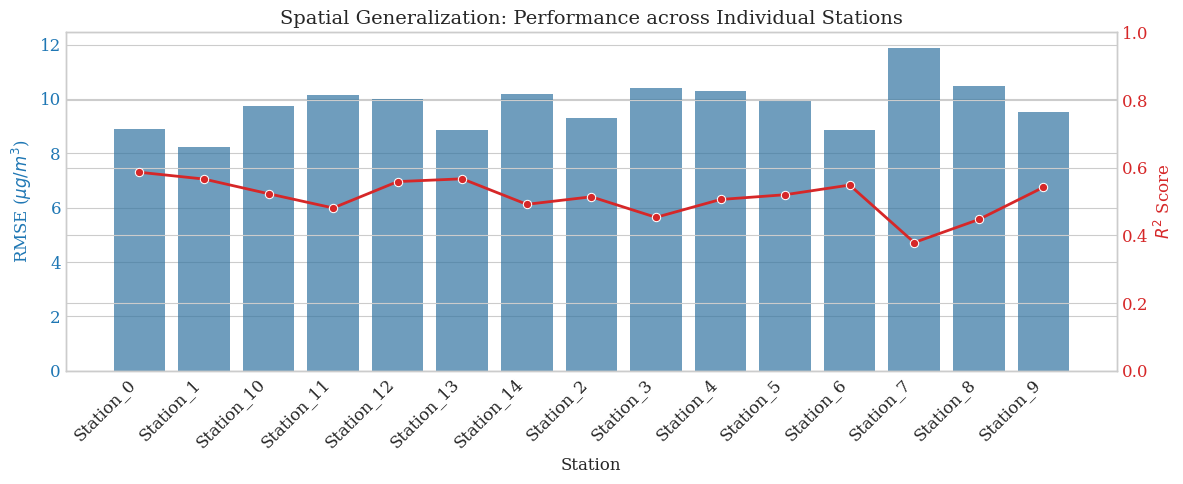

In [4]:
print("--- Performance by Station (Simulating Spatial CV Evaluation) ---")
station_metrics = []
for station, group in df.groupby('station_id'):
    m = eval_metrics(group['y_true'], group['y_pred'])
    station_metrics.append({'Station': station, 'RMSE': m['RMSE'], 'R²': m['R²']})

df_stations = pd.DataFrame(station_metrics)
display(df_stations.describe().round(3))

# Plotting Station Performance
fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(data=df_stations, x='Station', y='RMSE', color='#1f77b4', ax=ax1, alpha=0.7)
ax1.set_ylabel('RMSE ($\\mu g/m^3$)', color='#1f77b4', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()
sns.lineplot(data=df_stations, x='Station', y='R²', color='#d62728', marker='o', ax=ax2, linewidth=2)
ax2.set_ylabel('$R^2$ Score', color='#d62728', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 1.0)

plt.title('Spatial Generalization: Performance across Individual Stations', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Temporal Evaluation (Seasonal Performance)
Evaluating how the model performs across different seasons. Often, winter has higher PM2.5 and different meteorological conditions, leading to varied model performance.

--- Performance by Season ---


,Season,RMSE,R²,Count
1,Spring,9.656,0.446,1350
2,Summer,8.571,0.367,1350
0,Autumn,10.003,0.488,1350
3,Winter,10.838,0.231,1425


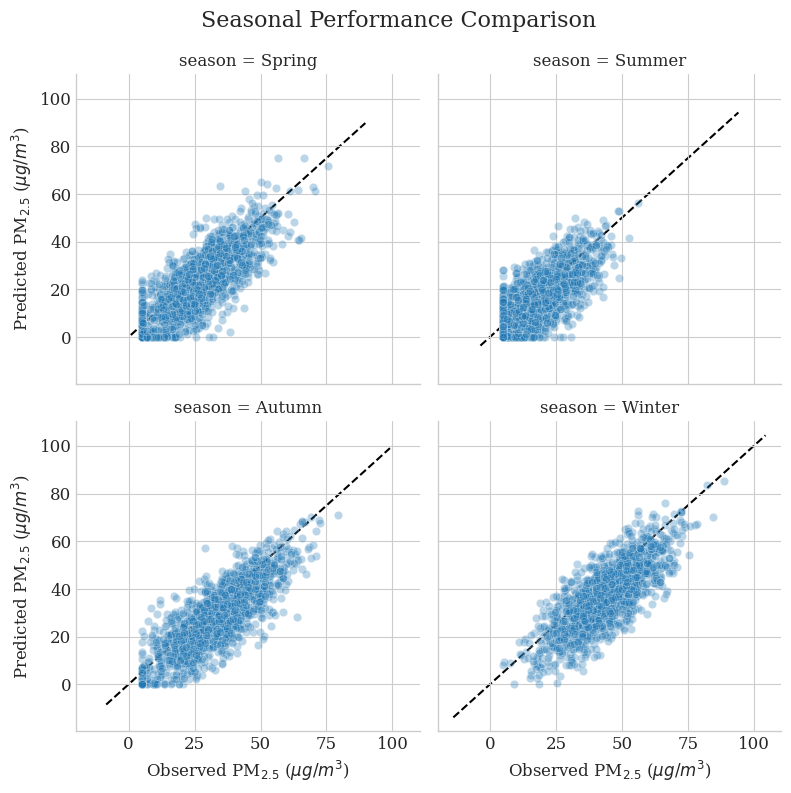

In [5]:
print("--- Performance by Season ---")
season_metrics = []
for season, group in df.groupby('season'):
    m = eval_metrics(group['y_true'], group['y_pred'])
    season_metrics.append({'Season': season, 'RMSE': m['RMSE'], 'R²': m['R²'], 'Count': len(group)})

df_season = pd.DataFrame(season_metrics)
# Order seasons logically
df_season['Season'] = pd.Categorical(df_season['Season'], categories=['Spring', 'Summer', 'Autumn', 'Winter'], ordered=True)
df_season = df_season.sort_values('Season')
display(df_season.round(3))

# Scatter plot stratified by season
g = sns.FacetGrid(df, col="season", col_order=['Spring', 'Summer', 'Autumn', 'Winter'], col_wrap=2, height=4, aspect=1)
g.map_dataframe(sns.scatterplot, x="y_true", y="y_pred", alpha=0.3)

def draw_1to1(**kwargs):
    ax = plt.gca()
    limits = [max(ax.get_xlim()[0], ax.get_ylim()[0]), min(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(limits, limits, 'k--', zorder=0)

g.map(draw_1to1)
g.set_axis_labels('Observed PM$_{2.5}$ ($\\mu g/m^3$)', 'Predicted PM$_{2.5}$ ($\\mu g/m^3$)')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Seasonal Performance Comparison', fontsize=16)
plt.show()

### 2.3 Leave-One-Group-Out CV (Concept Demonstration)
If you have access to the model training pipeline, you should use `GroupKFold` from scikit-learn. Here is how you structure the data for it.

In [6]:
# Example of setting up Spatial CV generator
gkf_spatial = GroupKFold(n_splits=5)
X_dummy = np.zeros(len(df)) # Placeholder for features

print("Spatial CV Folds (Grouping by Station_ID):")
fold = 1
for train_idx, test_idx in gkf_spatial.split(X_dummy, df['y_true'], groups=df['station_id']):
    test_stations = df.iloc[test_idx]['station_id'].unique()
    print(f"Fold {fold}: Holding out stations: {test_stations}")
    fold += 1
    if fold > 3: # Just show first 3 for brevity
        break

print("\nTo fully evaluate this, you must train the model inside this loop and predict on the held-out stations.")

Spatial CV Folds (Grouping by Station_ID):
Fold 1: Holding out stations: ['Station_4' 'Station_9' 'Station_12']
Fold 2: Holding out stations: ['Station_3' 'Station_8' 'Station_11']
Fold 3: Holding out stations: ['Station_2' 'Station_7' 'Station_10']

To fully evaluate this, you must train the model inside this loop and predict on the held-out stations.
